# Chronic Kidney Disease Prediction

## Problem Statement
Chronic Kidney Disease (CKD) is a serious condition that often goes undetected until it reaches advanced stages.
The goal of this project is to answer the following question:

**Can we accurately predict whether a patient has Chronic Kidney Disease based on clinical and lab test features?**

We will explore the dataset, clean it, engineer features, and train multiple machine learning models to find the best predictor.

## Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, RFE, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('kidney_disease.csv')
df

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [3]:
df.shape

(400, 26)

In [4]:
df.isnull().sum()


id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [5]:
df.dtypes


id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                   str
pc                    str
pcc                   str
ba                    str
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                   str
wc                    str
rc                    str
htn                   str
dm                    str
cad                   str
appet                 str
pe                    str
ane                   str
classification        str
dtype: object

## Data Cleaning

The raw dataset contains several quality issues that must be addressed before analysis:
- **Irrelevant columns:** The `id` column carries no predictive value and will be dropped.
- **Mixed types:** Columns `pcv`, `wc`, and `rc` are stored as strings due to non-numeric entries and will be coerced to numeric.
- **Whitespace:** Categorical text columns contain leading/trailing spaces that cause mismatches during encoding.
- **Missing values:** Skewed numerical features are filled with the median; normally distributed ones with the mean; categorical features with the mode.
- **Encoding:** All categorical binary columns are mapped to 0/1 for model compatibility.

In [6]:
df = df.drop(columns=["id"])

In [7]:
for col in ['pcv', 'wc', 'rc']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')



    

In [8]:
text_cols = df.select_dtypes(include=['object']).columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()


In [9]:
text_cols = df.select_dtypes(include=['object']).columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

In [10]:
median_cols = ["age", "bp", "bgr", "bu", "sc", "sod", "pot", "hemo", "pcv", "wc", "rc"]
mean_cols = ["sg", "al", "su"]
mode_cols = ["rbc", "pc", "pcc", "ba", "htn", "dm", "cad", "appet", "pe", "ane"]

for col in median_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

for col in mean_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

for col in mode_cols:
    if col in df.columns and not df[col].mode().empty:
        
        df[col] = df[col].fillna(df[col].mode()[0])


In [11]:
binary_mappings = {
    "rbc":   {"normal": 1, "abnormal": 0},
    "pc":    {"normal": 1, "abnormal": 0},
    "pcc":   {"present": 1, "notpresent": 0},
    "ba":    {"present": 1, "notpresent": 0},
    "htn":   {"yes": 1, "no": 0},
    "dm":    {"yes": 1, "no": 0},
    "cad":   {"yes": 1, "no": 0},
    "pe":    {"yes": 1, "no": 0},
    "ane":   {"yes": 1, "no": 0},
    "appet": {"good": 1, "poor": 0}
}

for col, mapping in binary_mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)

if 'classification' in df.columns:
    df['classification'] = df['classification'].map({"ckd": 1, "notckd": 0})


print("Remaining missing values per column:")
print(df.isnull().sum())

Remaining missing values per column:
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64


In [12]:
df.to_csv('cleaned_kidney_disease_data.csv', index=False)


## Exploratory Data Analysis



### Statistical Summary


In [13]:
print("=== Dataset Statistical Summary ===")
df.describe()

=== Dataset Statistical Summary ===


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,...,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,51.562500,76.575000,1.017408,1.016949,0.450142,0.882500,0.810000,0.105000,0.055000,145.062500,...,39.082500,8298.500000,4.737750,0.367500,0.34250,0.085000,0.795000,0.190000,0.150000,0.625000
std,16.982996,13.489785,0.005369,1.272318,1.029487,0.322418,0.392792,0.306937,0.228266,75.260774,...,8.162245,2529.593814,0.841439,0.482728,0.47514,0.279231,0.404207,0.392792,0.357519,0.484729
min,2.000000,50.000000,1.005000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,...,9.000000,2200.000000,2.100000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,70.000000,1.015000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,101.000000,...,34.000000,6975.000000,4.500000,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,55.000000,80.000000,1.017408,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,121.000000,...,40.000000,8000.000000,4.800000,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000,1.000000
75%,64.000000,80.000000,1.020000,2.000000,0.450142,1.000000,1.000000,0.000000,0.000000,150.000000,...,44.000000,9400.000000,5.100000,1.000000,1.00000,0.000000,1.000000,0.000000,0.000000,1.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,490.000000,...,54.000000,26400.000000,8.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


### Bivariate Analysis

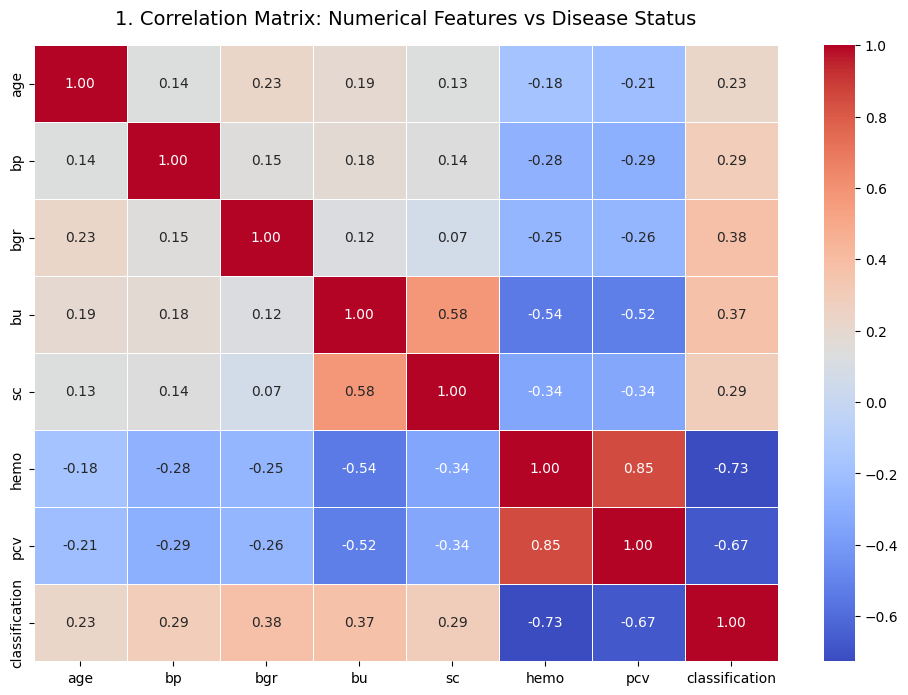

In [14]:
plt.figure(figsize=(12, 8))
numerical_subset = ['age', 'bp', 'bgr', 'bu', 'sc', 'hemo', 'pcv', 'classification']
corr_matrix = df[numerical_subset].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('1. Correlation Matrix: Numerical Features vs Disease Status', fontsize=14, pad=15)
plt.show()

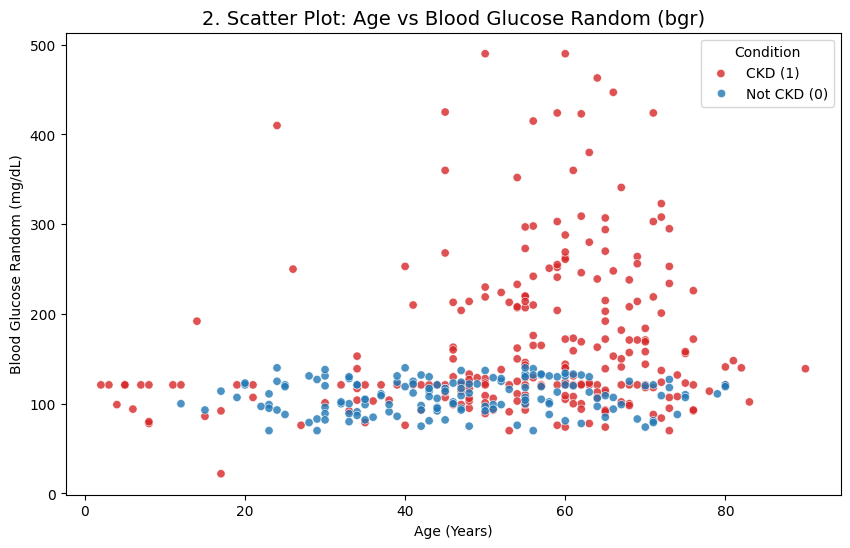

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='age', 
    y='bgr', 
    hue='classification', 
    palette={1: '#d62728', 0: '#1f77b4'}, 
    alpha=0.8
)
plt.title('2. Scatter Plot: Age vs Blood Glucose Random (bgr)', fontsize=14)
plt.xlabel('Age (Years)')
plt.ylabel('Blood Glucose Random (mg/dL)')

plt.legend(title='Condition', labels=['CKD (1)', 'Not CKD (0)'])
plt.show()

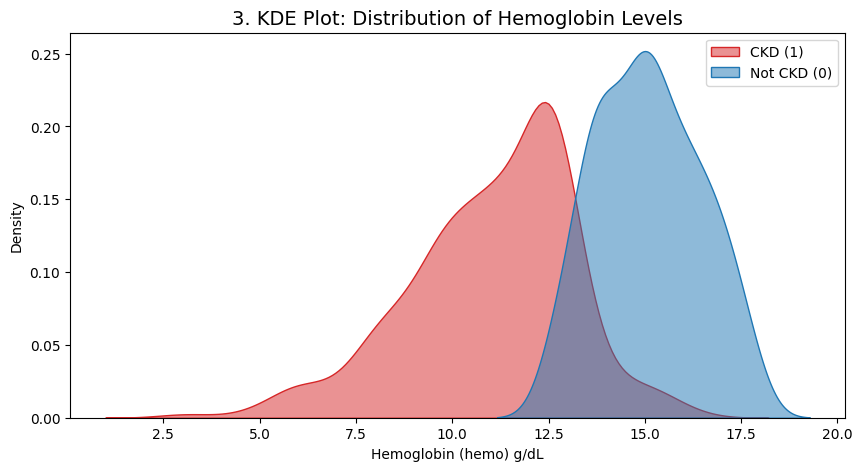

In [16]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['classification'] == 1], x='hemo', shade=True, color='#d62728', label='CKD (1)', alpha=0.5)
sns.kdeplot(data=df[df['classification'] == 0], x='hemo', shade=True, color='#1f77b4', label='Not CKD (0)', alpha=0.5)
plt.title('3. KDE Plot: Distribution of Hemoglobin Levels', fontsize=14)
plt.xlabel('Hemoglobin (hemo) g/dL')
plt.ylabel('Density')
plt.legend()
plt.show()

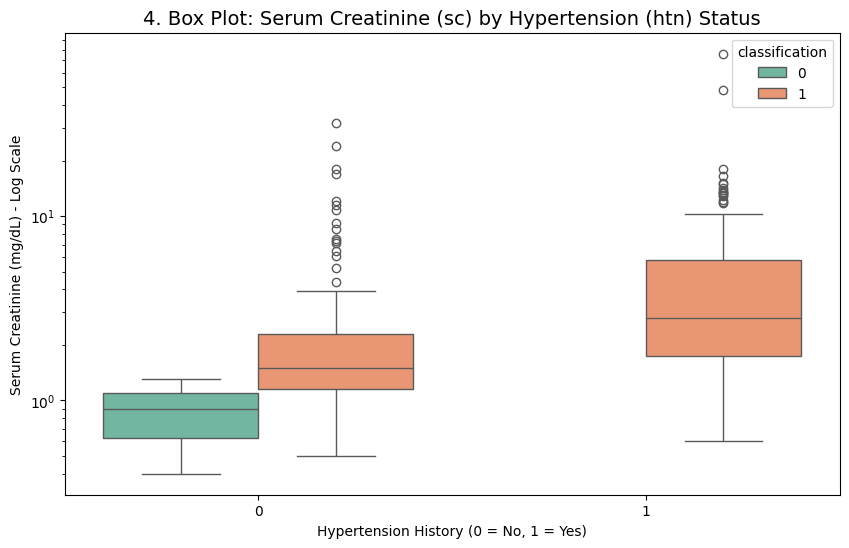

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='htn', y='sc', hue='classification', palette='Set2')
plt.yscale('log') 
plt.title('4. Box Plot: Serum Creatinine (sc) by Hypertension (htn) Status', fontsize=14)
plt.xlabel('Hypertension History (0 = No, 1 = Yes)')
plt.ylabel('Serum Creatinine (mg/dL) - Log Scale')
plt.show()

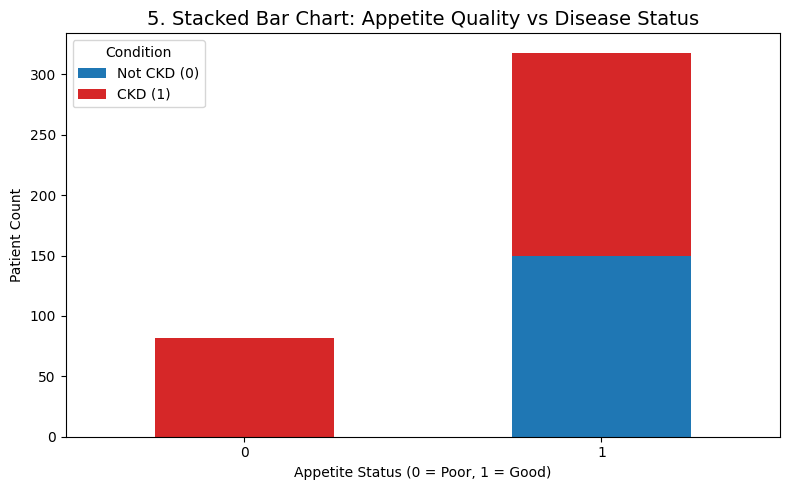

In [18]:
plt.figure(figsize=(8, 5))
appet_ct = pd.crosstab(df['appet'], df['classification'])
appet_ct.plot(kind='bar', stacked=True, color=['#1f77b4', '#d62728'], ax=plt.gca())

plt.title('5. Stacked Bar Chart: Appetite Quality vs Disease Status', fontsize=14)
plt.xlabel('Appetite Status (0 = Poor, 1 = Good)')
plt.ylabel('Patient Count')
plt.xticks(rotation=0)
plt.legend(title='Condition', labels=['Not CKD (0)', 'CKD (1)'])
plt.tight_layout()
plt.show()

### Univariate Analysis


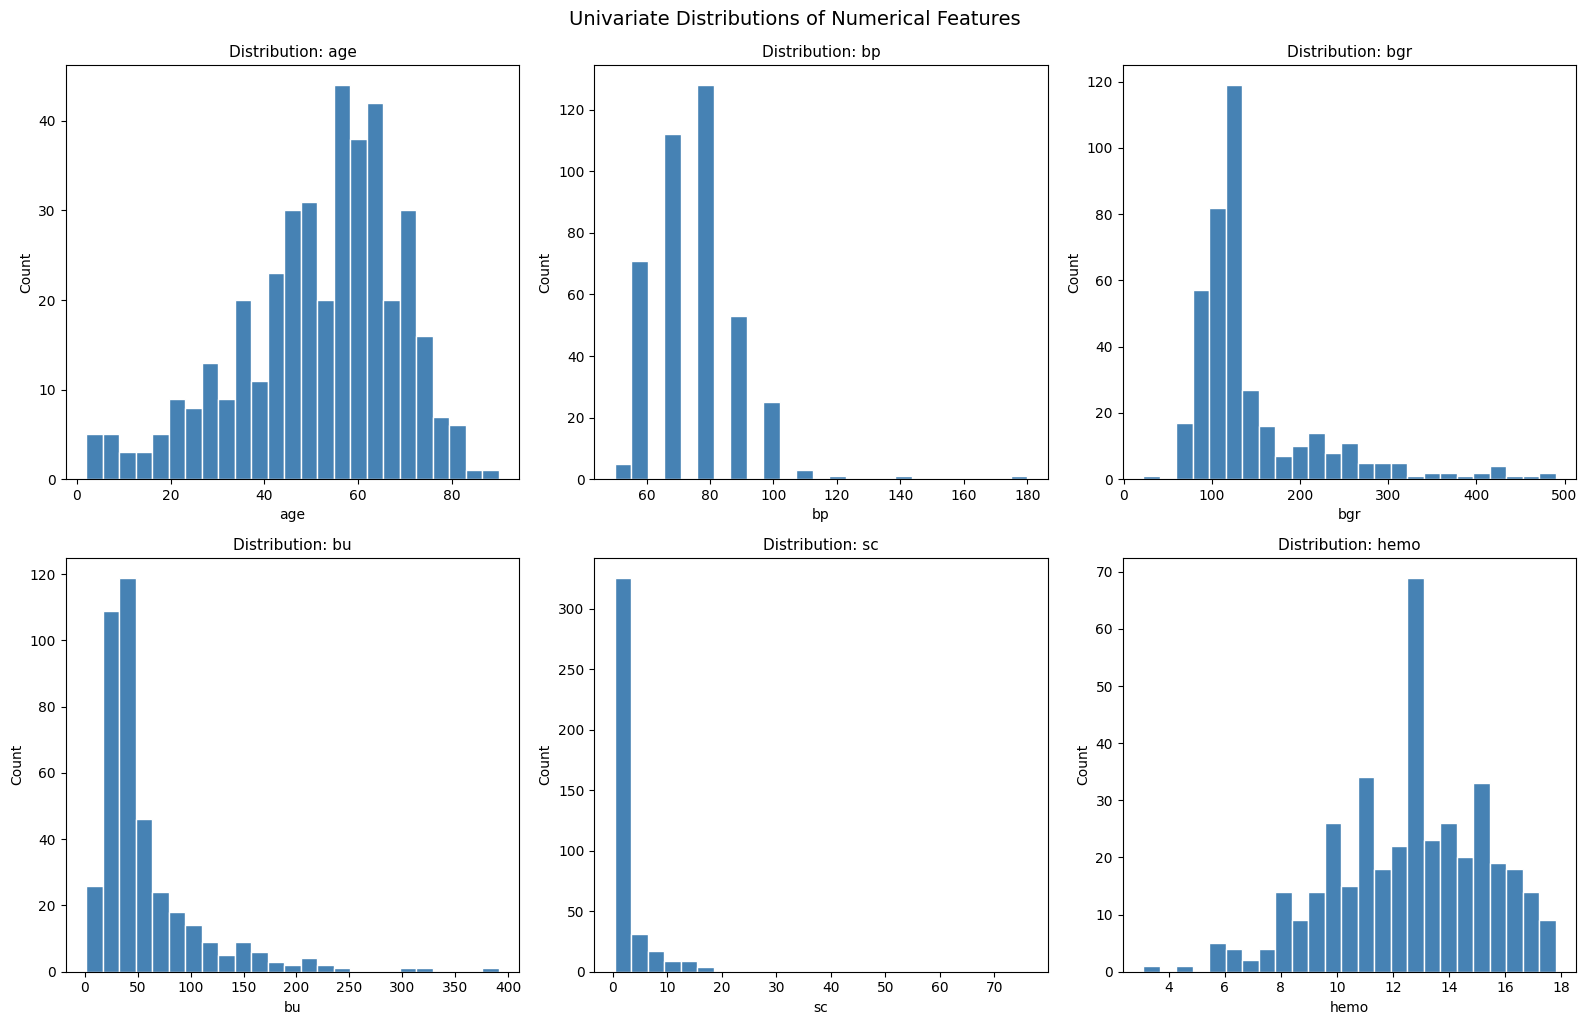

In [19]:
def plot_univariate(df, cols, title_prefix):
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    for i, col in enumerate(cols):
        axes[i].hist(df[col].dropna(), bins=25, color='steelblue', edgecolor='white')
        axes[i].set_title(f'{title_prefix}: {col}', fontsize=11)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
    plt.tight_layout()
    plt.suptitle('Univariate Distributions of Numerical Features', fontsize=14, y=1.02)
    plt.show()

num_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'hemo']
plot_univariate(df, num_cols, 'Distribution')


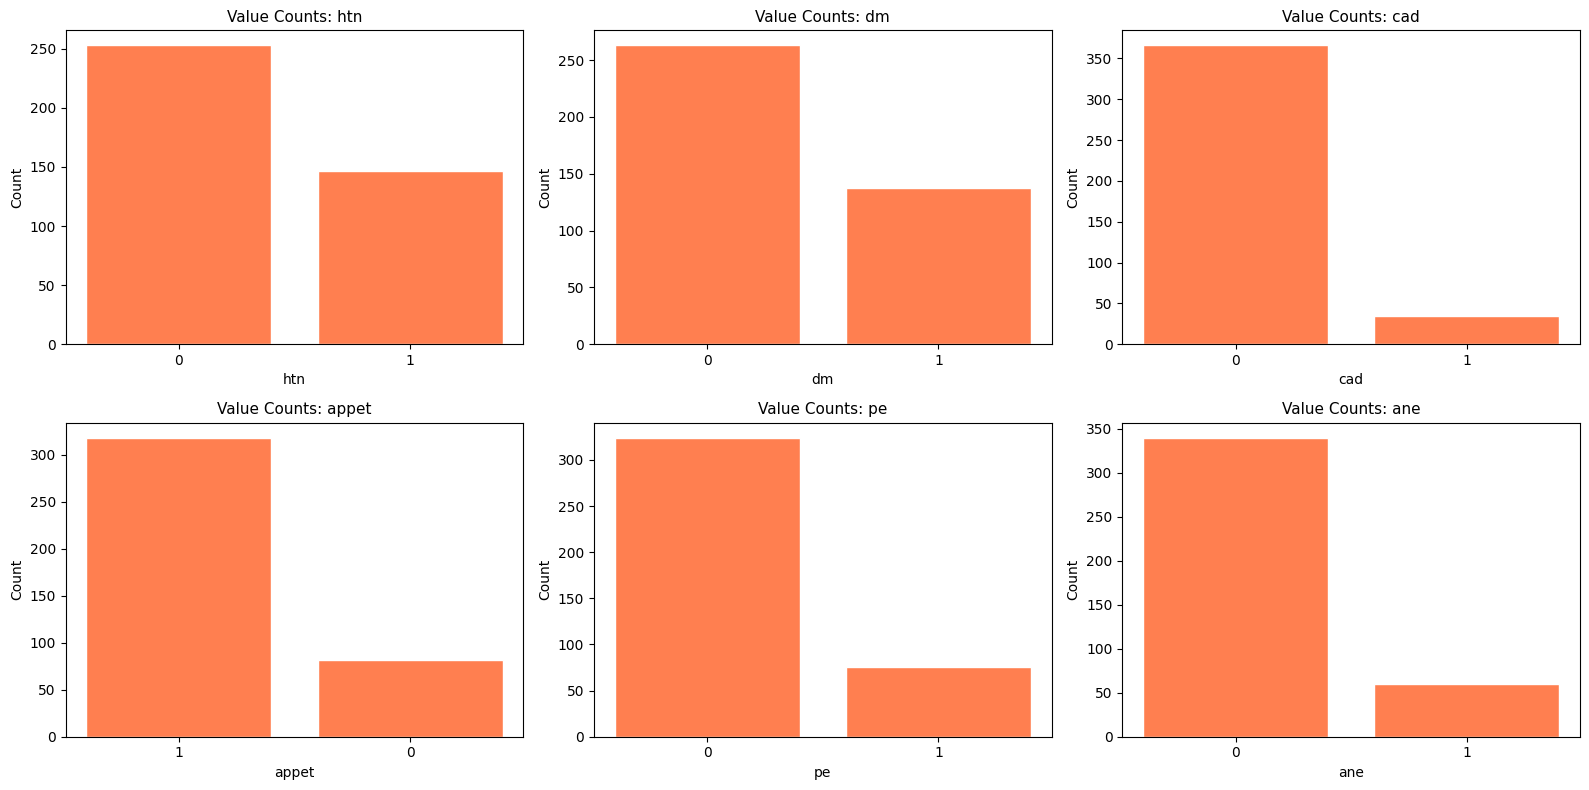

In [20]:
def plot_categorical_counts(df, cols):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()
    for i, col in enumerate(cols):
        counts = df[col].value_counts()
        axes[i].bar(counts.index.astype(str), counts.values, color='coral', edgecolor='white')
        axes[i].set_title(f'Value Counts: {col}', fontsize=11)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
    plt.tight_layout()
    plt.show()

cat_cols = ['htn', 'dm', 'cad', 'appet', 'pe', 'ane']
plot_categorical_counts(df, cat_cols)

## Feature Engineering & Selection

### New Features
Two new interaction features are created:
- `age_sc_interaction`: Captures the combined effect of age and serum creatinine — older patients with high creatinine are at greater risk.
- `hemo_bp_ratio`: Relates hemoglobin to blood pressure, which may signal anemia-related cardiovascular strain.

### Feature Selection — Filter Method (SelectKBest)
We use `SelectKBest` with the ANOVA F-score (`f_classif`) to rank features by their statistical relationship with the target variable, selecting the top 12.
This is a **Filter Method** — it evaluates features independently of any model, making it fast and unbiased.

In [21]:
df['age_sc_interaction'] = df['age'] * df['sc']
df['hemo_bp_ratio'] = df['hemo'] / (df['bp'] + 1) 
X = df.drop(columns=['classification'])
y = df['classification']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
selector = SelectKBest(score_func=f_classif, k=12)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)
selected_features = X.columns[selector.get_support()]
print("Selected Top 12 Features:\n", list(selected_features), "\n" + "="*50)

Selected Top 12 Features:
 ['sg', 'al', 'pc', 'bu', 'hemo', 'pcv', 'rc', 'htn', 'dm', 'appet', 'pe', 'hemo_bp_ratio'] 


## Modelling

### Baseline Model Comparison
Three algorithms are trained with default settings to compare their baseline performance before any tuning.

In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42)
}

print("--- Baseline Model Comparison ---")
for name, model in models.items():
    model.fit(X_train_selected, y_train)
    preds = model.predict(X_test_selected)
    print(f"{name} Base Accuracy: {accuracy_score(y_test, preds):.4f}")
print("="*50)

--- Baseline Model Comparison ---
Logistic Regression Base Accuracy: 0.9625
Random Forest Base Accuracy: 0.9875
Support Vector Machine Base Accuracy: 0.9875


### Parameter Tuning

**What is parameter tuning?**
Machine learning models have hyperparameters — settings that are not learned from data but set before training (e.g., number of trees, max depth).
Tuning means systematically trying different combinations to find the ones that give the best performance.

**Why is it important?**
Without tuning, a model uses default settings that may underfit or overfit the data. Tuning helps the model generalize better to new, unseen data.
We use `GridSearchCV` with 5-fold cross-validation to search over the hyperparameter grid.

In [24]:
print("--- Tuning Best Candidate (Random Forest) ---")
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train_selected, y_train)
best_model = grid_search.best_estimator_

print(f"Best Hyperparameters: {grid_search.best_params_}\n" + "="*50)

--- Tuning Best Candidate (Random Forest) ---
Best Hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


## Validation & Evaluation

**What is validation?**
Validation is the process of evaluating a model on data it was not trained on, to estimate real-world performance.

**Why is it important?**
If we only evaluate on training data, the model appears perfect but fails on new data (overfitting).
Cross-validation splits data into multiple folds and averages results — giving a more reliable performance estimate.

**Final Model Evaluation**

In [25]:
y_pred = best_model.predict(X_test_selected)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred)
}

print("--- Final Tuned Model Evaluation ---")

for metric_name, score in metrics.items():
    print(f"{metric_name:<12}: {score:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

--- Final Tuned Model Evaluation ---
Accuracy    : 0.9875
Precision   : 1.0000
Recall      : 0.9800
F1-Score    : 0.9899

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



**Confusion Matrix**

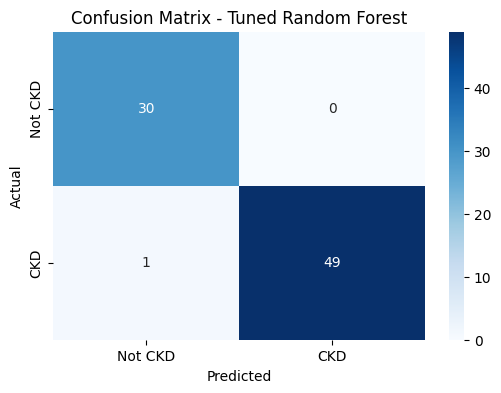

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not CKD','CKD'],
    yticklabels=['Not CKD','CKD']
)

plt.title('Confusion Matrix - Tuned Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Cross Validation**

In [27]:
cv_scores = cross_val_score(
    best_model,
    X_train_selected,
    y_train,
    cv=5,
    scoring='f1'
)

print("5-Fold CV F1 Scores:", cv_scores.round(3))
print(f"Mean F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
X_train.info()
y_train.value_counts()


5-Fold CV F1 Scores: [0.975 0.988 1.    1.    1.   ]
Mean F1: 0.9925 ± 0.0100
<class 'pandas.DataFrame'>
Index: 320 entries, 108 to 370
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 320 non-null    float64
 1   bp                  320 non-null    float64
 2   sg                  320 non-null    float64
 3   al                  320 non-null    float64
 4   su                  320 non-null    float64
 5   rbc                 320 non-null    int64  
 6   pc                  320 non-null    int64  
 7   pcc                 320 non-null    int64  
 8   ba                  320 non-null    int64  
 9   bgr                 320 non-null    float64
 10  bu                  320 non-null    float64
 11  sc                  320 non-null    float64
 12  sod                 320 non-null    float64
 13  pot                 320 non-null    float64
 14  hemo                320 non-null    float6

classification
1    200
0    120
Name: count, dtype: int64

**Model Comparison Chart**

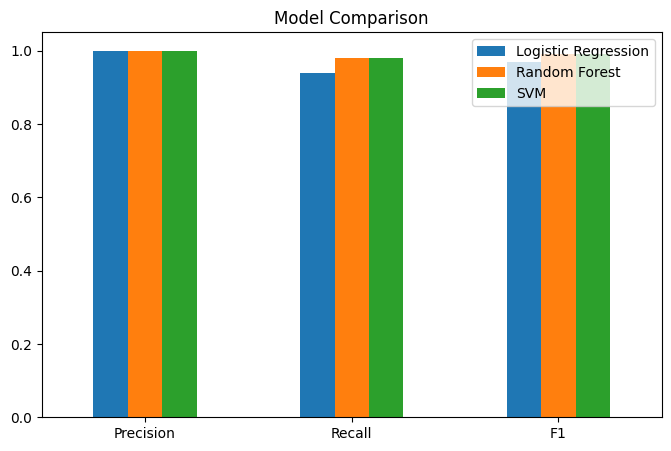

In [28]:

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_selected, y_train)
lr_preds = lr_model.predict(X_test_selected)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_selected, y_train)
rf_preds = rf_model.predict(X_test_selected)

svm_model = SVC(random_state=42)
svm_model.fit(X_train_selected, y_train)
svm_preds = svm_model.predict(X_test_selected)


results = {
    'Logistic Regression': lr_preds,
    'Random Forest': rf_preds,
    'SVM': svm_preds
}

metrics_compare = {
    name: [
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ]
    for name, pred in results.items()
}

comparison_df = pd.DataFrame(
    metrics_compare,
    index=['Precision','Recall','F1']
)

comparison_df.plot(kind='bar', figsize=(8,5))
plt.title('Model Comparison')
plt.xticks(rotation=0)
plt.show()

## Deployment

The trained pipeline (scaler + selector + model) has been saved using `joblib`.
A Streamlit web application (`app.py`) was built to allow users to input patient clinical values and receive a real-time CKD prediction.


**GitHub Repository:** [(https://github.com/MalakElamir369/ckd-predictor)]



**Web App Link:** [(https://ckd-predictor-jw98nbt99biunbkjdgw67v.streamlit.app)]




In [29]:
pipeline_export = {
    'scaler': scaler,
    'selector': selector,
    'model': best_model,
    'feature_names': list(X.columns)
}

model_filename = 'ckd_random_forest_pipeline.pkl'
joblib.dump(pipeline_export, model_filename)
print(f"🎉 Success! Production assets packed and saved safely to: '{model_filename}'")

🎉 Success! Production assets packed and saved safely to: 'ckd_random_forest_pipeline.pkl'
